In [49]:
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
walmart = pd.read_excel("/content/DA01 walmart_ Retail_Inventory_Optimization_Data.xlsx")
pd.set_option('display.max_columns', None)
walmart.set_index("transaction_id", inplace=True)
walmart

,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2824,843,Fridge,Electronics,3,188.46,2024-03-31 21:46:34,3,"Miami, FL",246,116,170,474,8,29,Other,98760.83,Silver,Credit Card,True,NaN,Stormy,False,Friday,True,172,179
2,1409,135,TV,Electronics,4,1912.04,2024-07-28 12:45:58,5,"Dallas, TX",43,70,212,135,4,34,Other,69781.93,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484
3,5506,391,Fridge,Electronics,4,1377.75,2024-06-10 04:55:47,1,"Los Angeles, CA",411,94,252,475,2,69,Other,77373.10,Platinum,Cash,False,NaN,Sunny,False,Tuesday,True,289,416
4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15 01:03:56,5,"Miami, FL",452,87,112,118,7,47,Other,33383.04,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446
5,4657,116,Laptop,Electronics,3,499.28,2024-09-13 00:45:01,6,"Chicago, IL",412,99,177,155,4,70,Female,108999.41,Bronze,Digital Wallet,False,NaN,Sunny,False,Thursday,True,287,469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,6898,852,Headphones,Appliances,1,682.15,2024-07-08 06:13:38,17,"New York, NY",75,80,217,413,1,67,Male,46960.75,Gold,Cash,False,NaN,Sunny,False,Wednesday,True,257,294
4997,8412,886,Laptop,Appliances,3,1418.09,2024-02-07 11:30:11,16,"Los Angeles, CA",207,98,234,430,2,66,Male,65182.86,Bronze,Digital Wallet,True,NaN,Sunny,True,Sunday,True,388,397
4998,8331,934,Fridge,Electronics,5,398.66,2024-08-20 00:38:16,16,"New York, NY",182,124,120,141,5,64,Female,90217.76,Bronze,Digital Wallet,True,NaN,Cloudy,False,Thursday,True,314,204


In [51]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1 to 5000
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             5000 non-null   int64         
 1   product_id              5000 non-null   int64         
 2   product_name            5000 non-null   object        
 3   category                5000 non-null   object        
 4   quantity_sold           5000 non-null   int64         
 5   unit_price              5000 non-null   float64       
 6   transaction_date        5000 non-null   datetime64[ns]
 7   store_id                5000 non-null   int64         
 8   store_location          5000 non-null   object        
 9   inventory_level         5000 non-null   int64         
 10  reorder_point           5000 non-null   int64         
 11  reorder_quantity        5000 non-null   int64         
 12  supplier_id             5000 non-null   int64        

In [52]:
walmart.isnull().sum()

,0
customer_id,0
product_id,0
product_name,0
category,0
quantity_sold,0
unit_price,0
transaction_date,0
store_id,0
store_location,0
inventory_level,0


In [53]:
walmart["promotion_type"] = walmart["promotion_type"].fillna("No Promotion")
walmart

,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2824,843,Fridge,Electronics,3,188.46,2024-03-31 21:46:34,3,"Miami, FL",246,116,170,474,8,29,Other,98760.83,Silver,Credit Card,True,No Promotion,Stormy,False,Friday,True,172,179
2,1409,135,TV,Electronics,4,1912.04,2024-07-28 12:45:58,5,"Dallas, TX",43,70,212,135,4,34,Other,69781.93,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484
3,5506,391,Fridge,Electronics,4,1377.75,2024-06-10 04:55:47,1,"Los Angeles, CA",411,94,252,475,2,69,Other,77373.10,Platinum,Cash,False,No Promotion,Sunny,False,Tuesday,True,289,416
4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15 01:03:56,5,"Miami, FL",452,87,112,118,7,47,Other,33383.04,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446
5,4657,116,Laptop,Electronics,3,499.28,2024-09-13 00:45:01,6,"Chicago, IL",412,99,177,155,4,70,Female,108999.41,Bronze,Digital Wallet,False,No Promotion,Sunny,False,Thursday,True,287,469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,6898,852,Headphones,Appliances,1,682.15,2024-07-08 06:13:38,17,"New York, NY",75,80,217,413,1,67,Male,46960.75,Gold,Cash,False,No Promotion,Sunny,False,Wednesday,True,257,294
4997,8412,886,Laptop,Appliances,3,1418.09,2024-02-07 11:30:11,16,"Los Angeles, CA",207,98,234,430,2,66,Male,65182.86,Bronze,Digital Wallet,True,No Promotion,Sunny,True,Sunday,True,388,397
4998,8331,934,Fridge,Electronics,5,398.66,2024-08-20 00:38:16,16,"New York, NY",182,124,120,141,5,64,Female,90217.76,Bronze,Digital Wallet,True,No Promotion,Cloudy,False,Thursday,True,314,204


In [56]:
walmart.duplicated().sum()

np.int64(0)

In [54]:
walmart.isnull().sum()

,0
customer_id,0
product_id,0
product_name,0
category,0
quantity_sold,0
unit_price,0
transaction_date,0
store_id,0
store_location,0
inventory_level,0


In [55]:
walmart.describe()

,customer_id,product_id,quantity_sold,unit_price,transaction_date,store_id,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_income,forecasted_demand,actual_demand
count,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,5542.497200,551.233400,2.982800,1023.467294,2024-05-11 05:10:52.154800128,10.525000,253.121800,99.788000,200.517000,300.12560,5.523000,44.124000,70041.627846,297.134000,299.08840
min,1001.000000,100.000000,1.000000,50.100000,2024-01-01 00:31:27,1.000000,0.000000,50.000000,100.000000,100.00000,1.000000,18.000000,20005.340000,100.000000,90.00000
25%,3279.000000,322.000000,2.000000,537.775000,2024-03-07 19:21:43.249999872,5.000000,130.000000,75.000000,150.750000,199.00000,3.000000,31.000000,44865.417500,195.000000,194.00000
50%,5558.000000,559.000000,3.000000,1029.175000,2024-05-11 20:03:01,11.000000,253.000000,100.000000,200.500000,299.00000,6.000000,44.000000,70188.290000,297.500000,299.00000
75%,7767.250000,776.000000,4.000000,1506.307500,2024-07-16 08:58:58,16.000000,377.250000,125.000000,251.000000,405.00000,8.000000,58.000000,95395.872500,395.000000,404.00000
max,9998.000000,999.000000,5.000000,1999.850000,2024-09-16 20:22:03,20.000000,500.000000,150.000000,300.000000,500.00000,10.000000,70.000000,119999.780000,500.000000,510.00000
std,2582.126997,258.826606,1.419474,559.614242,NaN,5.786888,142.885456,29.132387,58.257381,116.39486,2.863549,15.329358,29053.371736,115.568806,121.68078


In [57]:
walmart.head()

,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2824,843,Fridge,Electronics,3,188.46,2024-03-31 21:46:34,3,"Miami, FL",246,116,170,474,8,29,Other,98760.83,Silver,Credit Card,True,No Promotion,Stormy,False,Friday,True,172,179
2,1409,135,TV,Electronics,4,1912.04,2024-07-28 12:45:58,5,"Dallas, TX",43,70,212,135,4,34,Other,69781.93,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484
3,5506,391,Fridge,Electronics,4,1377.75,2024-06-10 04:55:47,1,"Los Angeles, CA",411,94,252,475,2,69,Other,77373.10,Platinum,Cash,False,No Promotion,Sunny,False,Tuesday,True,289,416
4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15 01:03:56,5,"Miami, FL",452,87,112,118,7,47,Other,33383.04,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446
5,4657,116,Laptop,Electronics,3,499.28,2024-09-13 00:45:01,6,"Chicago, IL",412,99,177,155,4,70,Female,108999.41,Bronze,Digital Wallet,False,No Promotion,Sunny,False,Thursday,True,287,469


Q1: What is the total sales volume across all Walmart stores?

In [149]:
walmart["quantity_sold"].sum()


np.int64(14914)

Q2: What is the average unit price of all products sold, by category?

In [156]:
round(walmart.groupby("category")[["unit_price"]].mean(),2)

,unit_price
category,
Appliances,1023.38
Electronics,1023.55


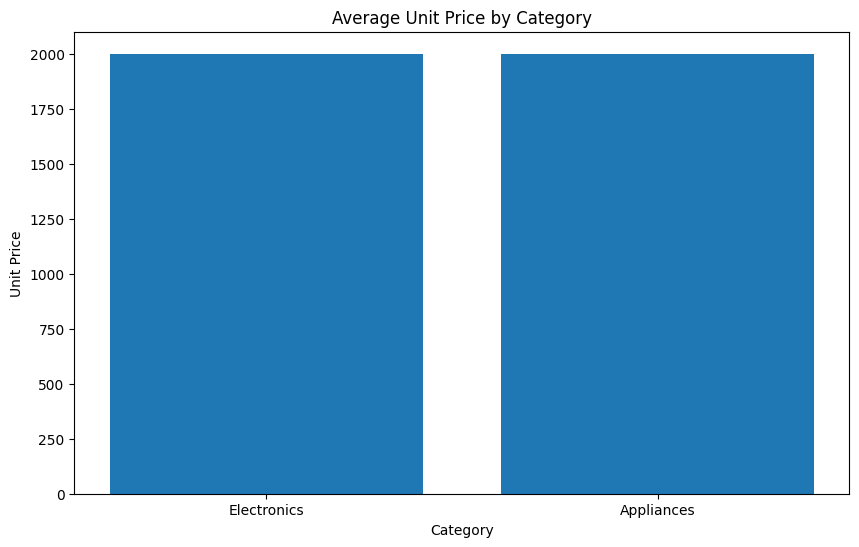

In [157]:
plt.figure(figsize=(10,6))
plt.bar(walmart["category"], walmart["unit_price"])
plt.xlabel("Category")
plt.ylabel("Unit Price")
plt.title("Average Unit Price by Category")
plt.show()

Q3: Which stores are underperforming in terms of sales volume?

In [170]:
walmart.groupby("store_id")[["quantity_sold"]].sum().sort_values(by = "quantity_sold" ,ascending=True)

,quantity_sold
store_id,
6,658
4,685
7,713
14,713
12,714
18,730
3,732
16,738
17,740


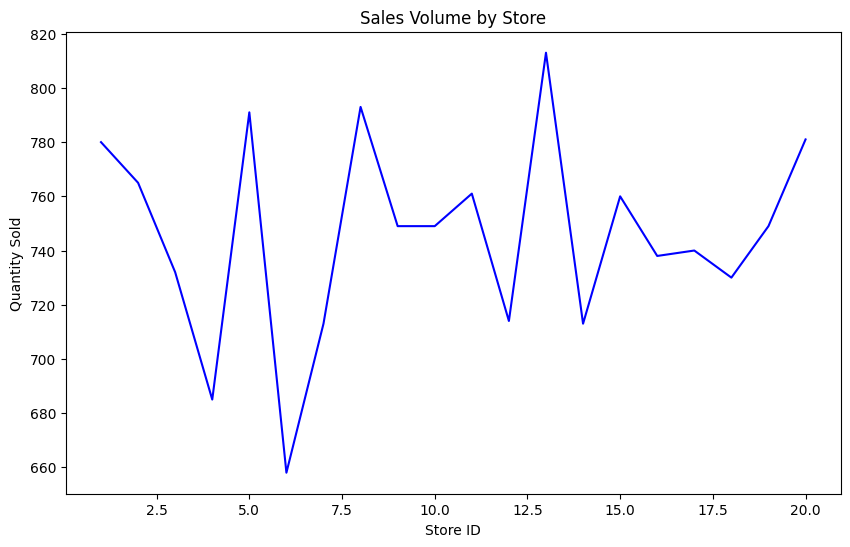

In [178]:
from matplotlib.lines import lineStyles
plt.figure(figsize=(10,6))
plt.plot(walmart.groupby("store_id")[["quantity_sold"]].sum().sort_index(ascending = True),color = "blue")
plt.xlabel("Store ID")
plt.ylabel("Quantity Sold")
plt.title("Sales Volume by Store")
plt.show()

Q4: What percentage of transactions involved promotions?

In [181]:
walmart["customer_id"].value_counts().sum()

np.int64(5000)

In [185]:
s =walmart["promotion_applied"].value_counts()/walmart["customer_id"].value_counts().sum()*100
s

,count
promotion_applied,
True,52.14
False,47.86


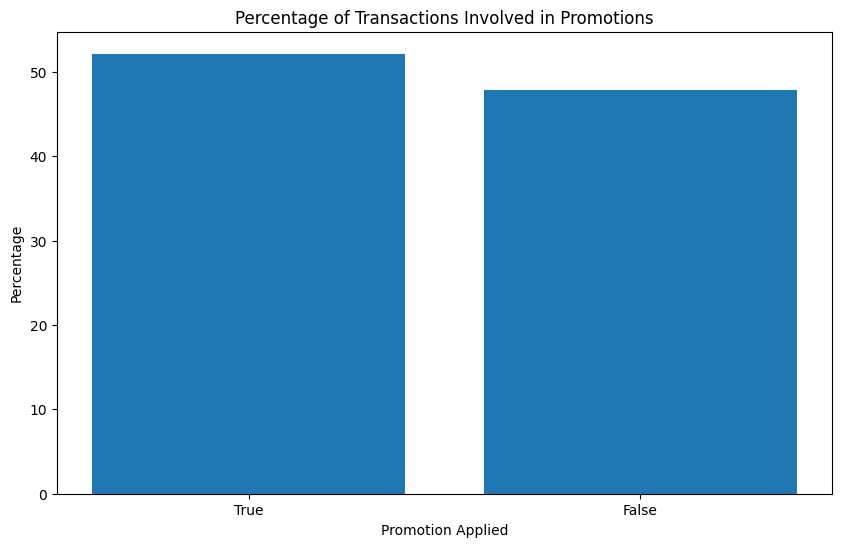

In [192]:
plt.figure(figsize=(10,6))
plt.bar(s.index.astype(str),s)
plt.xlabel("Promotion Applied")
plt.ylabel("Percentage")
plt.title("Percentage of Transactions Involved in Promotions")
plt.show()

Q5: What is the total revenue generated from sales during promotional events?

In [212]:
walmart["revenue"] = walmart["quantity_sold"]*walmart["unit_price"]
walmart

,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,revenue,Forecast,month
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2824,843,Fridge,Electronics,3,188.46,2024-03-31 21:46:34,3,"Miami, FL",246,116,170,474,8,29,Other,98760.83,Silver,Credit Card,True,No Promotion,Stormy,False,Friday,True,172,179,565.38,96.089385,3
2,1409,135,TV,Electronics,4,1912.04,2024-07-28 12:45:58,5,"Dallas, TX",43,70,212,135,4,34,Other,69781.93,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484,7648.16,22.520661,7
3,5506,391,Fridge,Electronics,4,1377.75,2024-06-10 04:55:47,1,"Los Angeles, CA",411,94,252,475,2,69,Other,77373.10,Platinum,Cash,False,No Promotion,Sunny,False,Tuesday,True,289,416,5511.00,69.471154,6
4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15 01:03:56,5,"Miami, FL",452,87,112,118,7,47,Other,33383.04,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446,911.55,39.013453,8
5,4657,116,Laptop,Electronics,3,499.28,2024-09-13 00:45:01,6,"Chicago, IL",412,99,177,155,4,70,Female,108999.41,Bronze,Digital Wallet,False,No Promotion,Sunny,False,Thursday,True,287,469,1497.84,61.194030,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,6898,852,Headphones,Appliances,1,682.15,2024-07-08 06:13:38,17,"New York, NY",75,80,217,413,1,67,Male,46960.75,Gold,Cash,False,No Promotion,Sunny,False,Wednesday,True,257,294,682.15,87.414966,7
4997,8412,886,Laptop,Appliances,3,1418.09,2024-02-07 11:30:11,16,"Los Angeles, CA",207,98,234,430,2,66,Male,65182.86,Bronze,Digital Wallet,True,No Promotion,Sunny,True,Sunday,True,388,397,4254.27,97.732997,2
4998,8331,934,Fridge,Electronics,5,398.66,2024-08-20 00:38:16,16,"New York, NY",182,124,120,141,5,64,Female,90217.76,Bronze,Digital Wallet,True,No Promotion,Cloudy,False,Thursday,True,314,204,1993.30,46.078431,8


In [222]:
s= walmart[walmart["promotion_applied"] == True].groupby("promotion_applied")["revenue"].sum()
s

,revenue
promotion_applied,
True,8062411.03


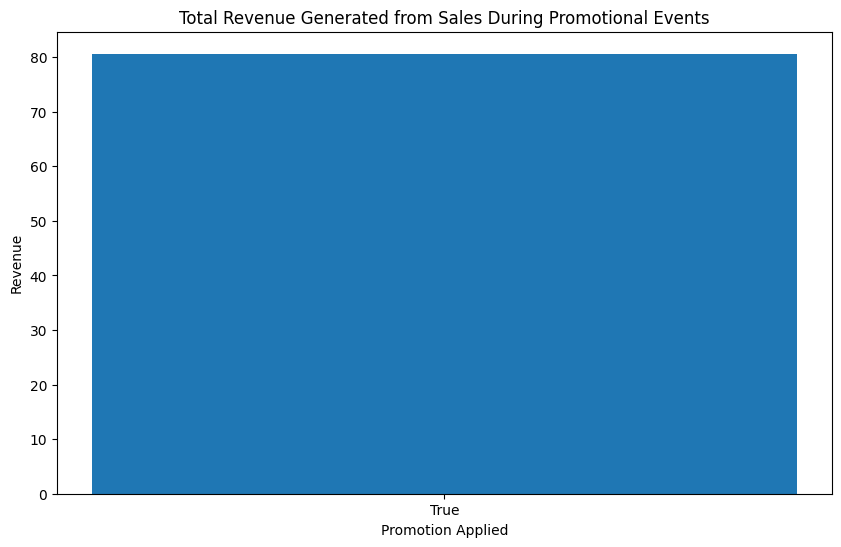

In [228]:
plt.figure(figsize=(10,6))
plt.bar(s.index.astype(str),s/1e5)
plt.xlabel("Promotion Applied")
plt.ylabel("Revenue")
plt.title("Total Revenue Generated from Sales During Promotional Events")
plt.show()

In [254]:
total_revenue = walmart["revenue"].sum()   # total revenue
total_revenue

np.float64(15263601.45)

Q6: Which product categories see the largest increase in demand during

In [229]:
s = walmart[walmart["holiday_indicator"] == True].groupby("category")["quantity_sold"].sum()
s


,quantity_sold
category,
Appliances,3576
Electronics,3880


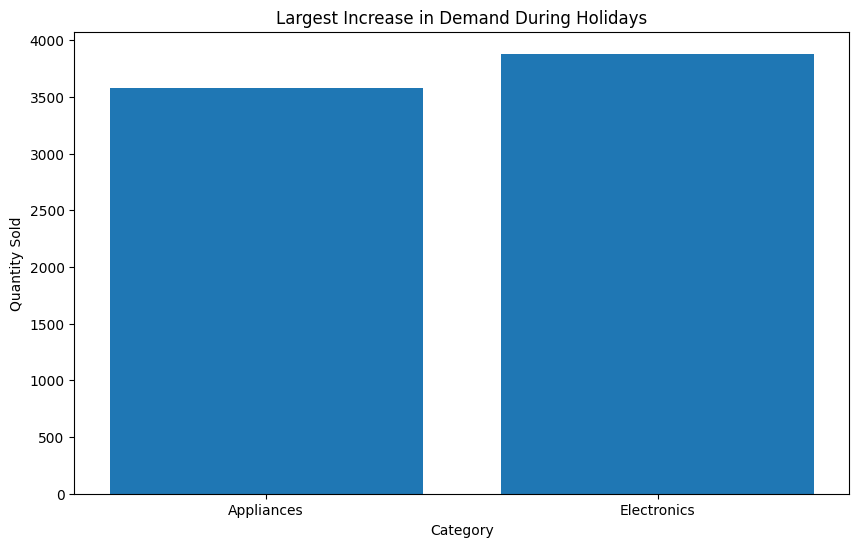

In [230]:
plt.figure(figsize=(10,6))
plt.bar(s.index,s.values)
plt.xlabel("Category")
plt.ylabel("Quantity Sold")
plt.title("Largest Increase in Demand During Holidays")
plt.show()

Q7: What is the correlation between weather conditions and sales performance?

In [232]:
s = walmart.groupby("weather_conditions")["revenue"].sum()
s

,revenue
weather_conditions,
Cloudy,3878416.82
Rainy,3562222.42
Stormy,3843358.52
Sunny,3979603.69


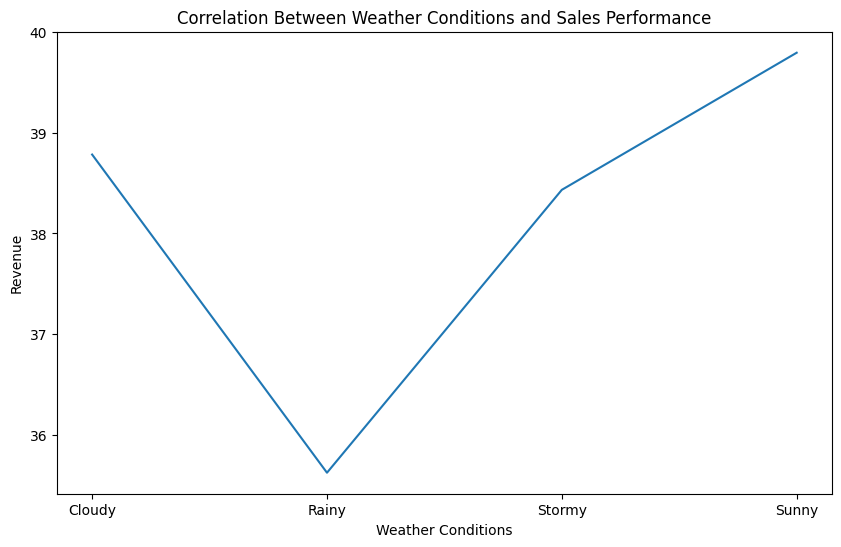

In [236]:
plt.figure(figsize=(10,6))
plt.plot(s/1e5)
plt.xlabel("Weather Conditions")
plt.ylabel("Revenue")
plt.title("Correlation Between Weather Conditions and Sales Performance")
plt.show()

Q8: How does customer loyalty level affect purchasing patterns?

In [238]:
s=  walmart.groupby("customer_loyalty_level")["quantity_sold"].sum().sort_values(ascending=False)
s

,quantity_sold
customer_loyalty_level,
Platinum,3896
Silver,3827
Bronze,3714
Gold,3477


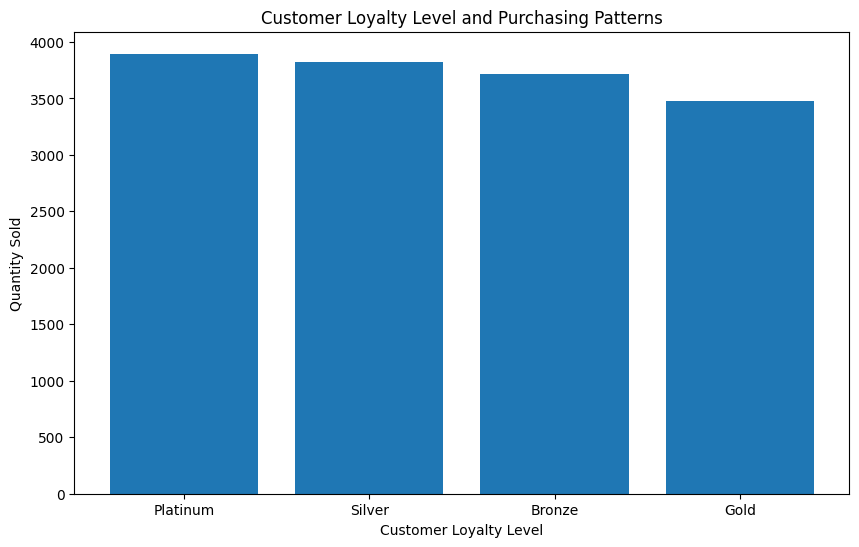

In [241]:
plt.figure(figsize=(10,6))
plt.bar(s.index,s.values)
plt.xlabel("Customer Loyalty Level")
plt.ylabel("Quantity Sold")
plt.title("Customer Loyalty Level and Purchasing Patterns")
plt.show()

Q9: What is the forecast accuracy for each store location?

In [119]:
walmart["Forecast"] = (1-abs(walmart["forecasted_demand"]- walmart["actual_demand"])/walmart["actual_demand"])*100
walmart


,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,inventory_level,reorder_point,reorder_quantity,supplier_id,supplier_lead_time,customer_age,customer_gender,customer_income,customer_loyalty_level,payment_method,promotion_applied,promotion_type,weather_conditions,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,revenue,Forecast
transaction_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2824,843,Fridge,Electronics,3,188.46,2024-03-31 21:46:34,3,"Miami, FL",246,116,170,474,8,29,Other,98760.83,Silver,Credit Card,True,No Promotion,Stormy,False,Friday,True,172,179,565.38,96.089385
2,1409,135,TV,Electronics,4,1912.04,2024-07-28 12:45:58,5,"Dallas, TX",43,70,212,135,4,34,Other,69781.93,Gold,Cash,True,Percentage Discount,Rainy,False,Monday,True,109,484,7648.16,22.520661
3,5506,391,Fridge,Electronics,4,1377.75,2024-06-10 04:55:47,1,"Los Angeles, CA",411,94,252,475,2,69,Other,77373.10,Platinum,Cash,False,No Promotion,Sunny,False,Tuesday,True,289,416,5511.00,69.471154
4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15 01:03:56,5,"Miami, FL",452,87,112,118,7,47,Other,33383.04,Silver,Cash,True,Percentage Discount,Sunny,True,Sunday,False,174,446,911.55,39.013453
5,4657,116,Laptop,Electronics,3,499.28,2024-09-13 00:45:01,6,"Chicago, IL",412,99,177,155,4,70,Female,108999.41,Bronze,Digital Wallet,False,No Promotion,Sunny,False,Thursday,True,287,469,1497.84,61.194030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4996,6898,852,Headphones,Appliances,1,682.15,2024-07-08 06:13:38,17,"New York, NY",75,80,217,413,1,67,Male,46960.75,Gold,Cash,False,No Promotion,Sunny,False,Wednesday,True,257,294,682.15,87.414966
4997,8412,886,Laptop,Appliances,3,1418.09,2024-02-07 11:30:11,16,"Los Angeles, CA",207,98,234,430,2,66,Male,65182.86,Bronze,Digital Wallet,True,No Promotion,Sunny,True,Sunday,True,388,397,4254.27,97.732997
4998,8331,934,Fridge,Electronics,5,398.66,2024-08-20 00:38:16,16,"New York, NY",182,124,120,141,5,64,Female,90217.76,Bronze,Digital Wallet,True,No Promotion,Cloudy,False,Thursday,True,314,204,1993.30,46.078431


In [243]:
s = round(walmart.groupby("store_location")["Forecast"].sum(),2)
s

,Forecast
store_location,
"Chicago, IL",40261.71
"Dallas, TX",39633.06
"Los Angeles, CA",44972.47
"Miami, FL",37065.26
"New York, NY",38433.89


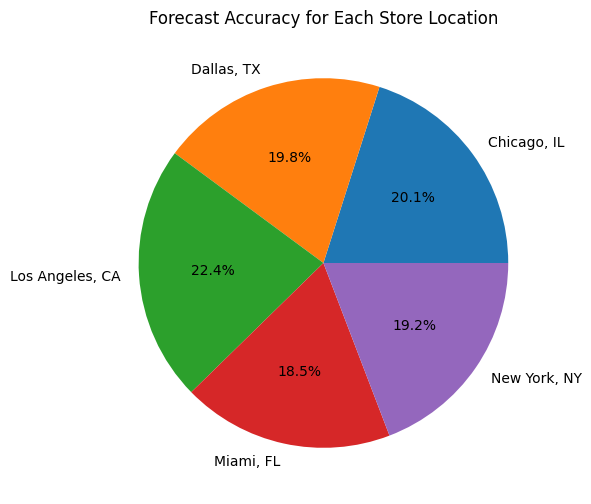

In [245]:
plt.figure(figsize=(10,6))
plt.pie(s.values, labels=s.index, autopct='%1.1f%%')
plt.title("Forecast Accuracy for Each Store Location")
plt.show()

Q10: What is the stockout rate at each store?

In [129]:
stock_rate = walmart.groupby("store_id")[["stockout_indicator"]].mean().reset_index()
stock_rate["stockout_rate%"] = round(stock_rate["stockout_indicator"]*100,2)
stock_rate


,store_id,stockout_indicator,stockout_rate%
0,1,0.520913,52.09
1,2,0.520000,52.00
2,3,0.474104,47.41
3,4,0.510730,51.07
4,5,0.550562,55.06
5,6,0.488789,48.88
6,7,0.471074,47.11
7,8,0.511538,51.15
8,9,0.542510,54.25
9,10,0.512295,51.23


In [135]:
walmart["month"] = pd.to_datetime(walmart["transaction_date"]).dt.month



In [249]:
s = walmart.groupby("month")["revenue"].sum().sort_index(ascending=True)
s

,revenue
month,
1,1731651.65
2,1767062.38
3,1833450.84
4,1739800.75
5,1786559.47
6,1600978.97
7,1878513.51
8,2018315.81
9,907268.07


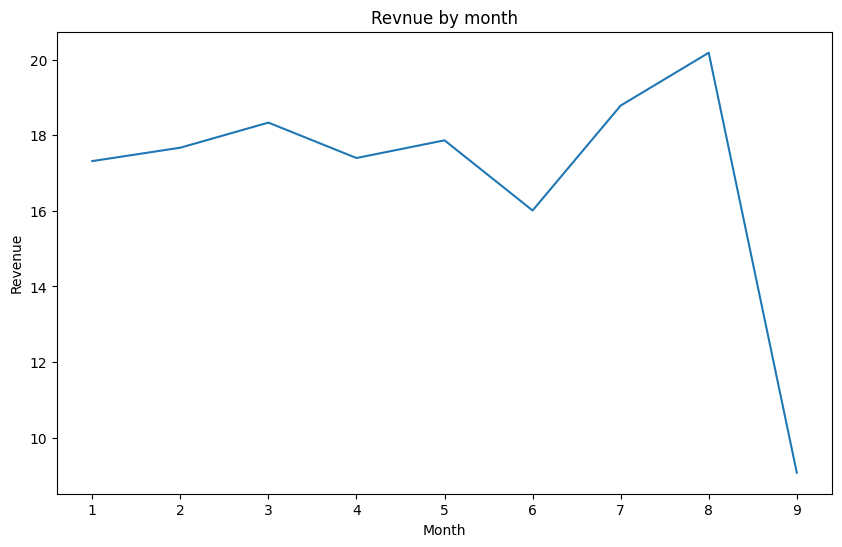

In [253]:
plt.figure(figsize=(10,6))
plt.plot(s/1e5)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Revnue by month")
plt.show()

conclusion

1.This is a walmart dataset that is used to analyze it to find key insight and optimize it there is total 5000 rows and 29 columns present in this dataset.

2.total sales is nearly 15000

3.Average unite price by category Appliances	1023.38,Electronics	1023.55

4.number 6 is a under proforming

5.true is higher used for promotion

6.total revenue generated in true more than 8000000

7.appliance highest sold category

8.sunny weather condition highest sales

9.customer loyalty in highest in platinum

10.highest revenue generated in jan